Entries: 100000
Volume counts:
Counter({1: 201757, 2: 162280, 4: 73405, 5: 961, 6: 918})

Process code counts:
[(1092, 253841), (1000, 100000), (2013, 43206), (2002, 29269), (2012, 7252), (2010, 3788), (2003, 1073), (2011, 892)]
Detected events used: 13013
Scatter origin points used: 13784
Image max = 2.0
Nonzero pixels = 16


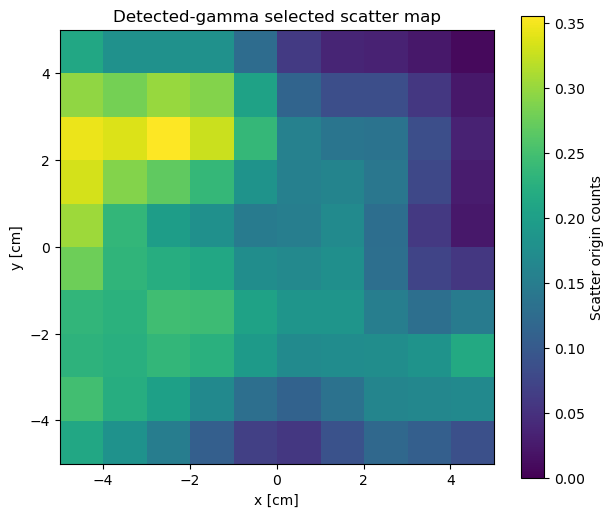

In [10]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# =========================
# USER SETTINGS
# =========================
root_file = "phantom.root"
tree_name = "t"

detector_vlms = [4, 5, 6]      # 3 detectors
phantom_vlms = [2, 3]          # phantom + tumor, change if needed

xmin, xmax = -5.0, 5.0
ymin, ymax = -5.0, 5.0
nx, ny = 10, 10

# If you know Compton process code, put it here.
# If not known, leave as None first.
compton_process_code = None    # example: 2012 or 2013, depends on your tree

# =========================
# OPEN ROOT FILE
# =========================
f = ROOT.TFile.Open(root_file)
if not f or f.IsZombie():
    raise RuntimeError("Could not open ROOT file")

t = f.Get(tree_name)
if not t:
    raise RuntimeError("Could not find tree")

print("Entries:", t.GetEntries())

# =========================
# CHECK PROCESS CODES
# =========================
pro_counter = Counter()
vlm_counter = Counter()

for entry in t:
    n = min(len(entry.pdg), len(entry.vlm), len(entry.pro))
    for i in range(n):
        vlm_counter[int(entry.vlm[i])] += 1
        pro_counter[int(entry.pro[i])] += 1

print("Volume counts:")
print(vlm_counter)

print("\nProcess code counts:")
print(pro_counter.most_common(20))

# =========================
# IMAGE ARRAY
# =========================
image = np.zeros((ny, nx))

def fill_image(x, y):
    if x < xmin or x > xmax or y < ymin or y > ymax:
        return

    ix = int((x - xmin) / (xmax - xmin) * nx)
    iy = int((y - ymin) / (ymax - ymin) * ny)

    if 0 <= ix < nx and 0 <= iy < ny:
        image[iy, ix] += 1.0

# =========================
# MAIN LOOP
# =========================
used_events = 0
used_scatter_points = 0

for entry in t:

    n = min(
        len(entry.pdg),
        len(entry.vlm),
        len(entry.x),
        len(entry.y),
        len(entry.z),
        len(entry.de),
        len(entry.pro),
        len(entry.stp)
    )

    # Step 1: event must have gamma reaching detector
    detected = False

    for i in range(n):
        if int(entry.pdg[i]) == 22 and int(entry.vlm[i]) in detector_vlms:
            detected = True
            break

    if not detected:
        continue

    used_events += 1

    # Step 2: map gamma energy-depositing scatter points in phantom/tumor
    for i in range(n):

        if int(entry.pdg[i]) != 22:
            continue

        if int(entry.vlm[i]) not in phantom_vlms:
            continue

       # if float(entry.de[i]) <= 0:
           # continue

        x = float(entry.x[i])
        y = float(entry.y[i])

        fill_image(x, y)
        used_scatter_points += 1

print("Detected events used:", used_events)
print("Scatter origin points used:", used_scatter_points)
print("Image max =", image.max())
print("Nonzero pixels =", np.count_nonzero(image))

# =========================
# PLOT
# =========================
from scipy.ndimage import gaussian_filter

image_smooth = gaussian_filter(image, sigma=1.2)

plt.figure(figsize=(7, 6))
plt.imshow(
    image_smooth,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    aspect="equal",
    vmin=0
)
plt.colorbar(label="Scatter origin counts")
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title("Detected-gamma selected scatter map")
plt.show()